In [ ]:
!pip install evaluate

In [2]:
import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)

import torch
import evaluate

from pathlib import Path
from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import matplotlib.pyplot as plt

In [3]:
MODEL_NAME = "roberta-base"

NUM_LABELS = 5

MAX_LENGTH = 128

BATCH_SIZE = 32

LEARNING_RATE = 2e-5

NUM_EPOCHS = 1

RANDOM_STATE = 42

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
train_df = pd.read_csv("/kaggle/input/datasets/maslri/split-validation-amazon-review-sentiment-dataset/train_split.csv")
valid_df = pd.read_csv("/kaggle/input/datasets/maslri/split-validation-amazon-review-sentiment-dataset/valid_split.csv")

print(train_df.shape)
print(valid_df.shape)

/tmp/ipykernel_22/1463717118.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv("/kaggle/input/datasets/maslri/split-validation-amazon-review-sentiment-dataset/train_split.csv")


(671155, 11)
(167789, 11)


/tmp/ipykernel_22/1463717118.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  valid_df = pd.read_csv("/kaggle/input/datasets/maslri/split-validation-amazon-review-sentiment-dataset/valid_split.csv")


In [6]:
train_df = train_df[["reviewText", "overall"]].copy()
valid_df = valid_df[["reviewText", "overall"]].copy()

In [7]:
train_df["label"] = train_df["overall"] - 1
valid_df["label"] = valid_df["overall"] - 1

In [8]:
train_dataset = Dataset.from_pandas(train_df[["reviewText", "label"]])
valid_dataset = Dataset.from_pandas(valid_df[["reviewText", "label"]])

In [9]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [10]:
def tokenize(batch):
    return tokenizer(
        batch["reviewText"],
        truncation=True,
        padding=False,
        max_length=MAX_LENGTH,
    )

In [11]:
train_dataset = train_dataset.map(
    tokenize,
    batched=True,
)

valid_dataset = valid_dataset.map(
    tokenize,
    batched=True,
)

Map:   0%|          | 0/671155 [00:00<?, ? examples/s]

Map:   0%|          | 0/167789 [00:00<?, ? examples/s]

In [12]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [13]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
)

model.to(device)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [14]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(
        logits,
        axis=1,
    )
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
    )
    acc = accuracy_score(
        labels,
        predictions,
    )
    macro_f1 = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
    )[2]
    return {
        "accuracy": acc,
        "weighted_f1": f1,
        "macro_f1": macro_f1,
    }

In [15]:
training_args = TrainingArguments(

    output_dir="../artifacts/roberta",

    eval_strategy="epoch",

    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    learning_rate=LEARNING_RATE,

    per_device_train_batch_size=BATCH_SIZE,

    per_device_eval_batch_size=BATCH_SIZE,

    num_train_epochs=NUM_EPOCHS,

    weight_decay=0.01,

    fp16=True,

    logging_steps=200,

    report_to="none",
)

In [16]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [17]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Weighted F1,Macro F1
1,1.218789,1.210713,0.755568,0.746834,0.624655


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=10487, training_loss=1.2948621304460097, metrics={'train_runtime': 9294.2709, 'train_samples_per_second': 72.212, 'train_steps_per_second': 1.128, 'total_flos': 4.414826422635648e+16, 'train_loss': 1.2948621304460097, 'epoch': 1.0})

In [18]:
metrics = trainer.evaluate()
metrics

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 1.2107133865356445,
 'eval_accuracy': 0.7555680050539666,
 'eval_weighted_f1': 0.7468344655472787,
 'eval_macro_f1': 0.6246552137175643,
 'eval_runtime': 713.4889,
 'eval_samples_per_second': 235.167,
 'eval_steps_per_second': 3.675,
 'epoch': 1.0}

In [19]:
predictions = trainer.predict(valid_dataset)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [20]:
from sklearn.metrics import classification_report

y_true = predictions.label_ids

y_pred = np.argmax(
    predictions.predictions,
    axis=1,
)

print(
    classification_report(
        y_true + 1,
        y_pred + 1,
    )
)

              precision    recall  f1-score   support

           1       0.70      0.78      0.74     16590
           2       0.47      0.36      0.41     11351
           3       0.54      0.51      0.52     16248
           4       0.61      0.52      0.56     31303
           5       0.86      0.92      0.89     92297

    accuracy                           0.76    167789
   macro avg       0.64      0.62      0.62    167789
weighted avg       0.74      0.76      0.75    167789



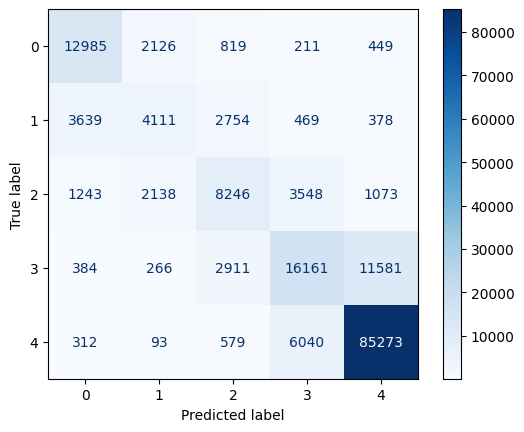

In [21]:
cm = confusion_matrix(
    y_true,
    y_pred,
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
)

disp.plot(cmap="Blues")

plt.show()

In [22]:
trainer.save_model("/kaggle/working/artifacts/models/roberta")
tokenizer.save_pretrained("/kaggle/working/artifacts/models/roberta")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/kaggle/working/artifacts/models/roberta/tokenizer_config.json',
 '/kaggle/working/artifacts/models/roberta/tokenizer.json')

In [23]:
text = """
This product is absolutely amazing.
"""

inputs = tokenizer(
    text,
    return_tensors="pt",
).to(device)

with torch.no_grad():
    outputs = model(**inputs)

prediction = torch.argmax(
    outputs.logits,
    dim=1,
)

print(
    prediction.item()+1
)

5
